=== STEP 1: CRASH FLAG DISTRIBUTION ===
Server_Crash_Flag
False    7063
True      437
Name: count, dtype: int64

===  STEP 2: ROWS REMAINING AFTER INVERSION FILTER ===
Original Logs: 7500 | Clean Operational Logs: 7063

💾 'cleaned_network_performance_report.csv' compiled successfully.



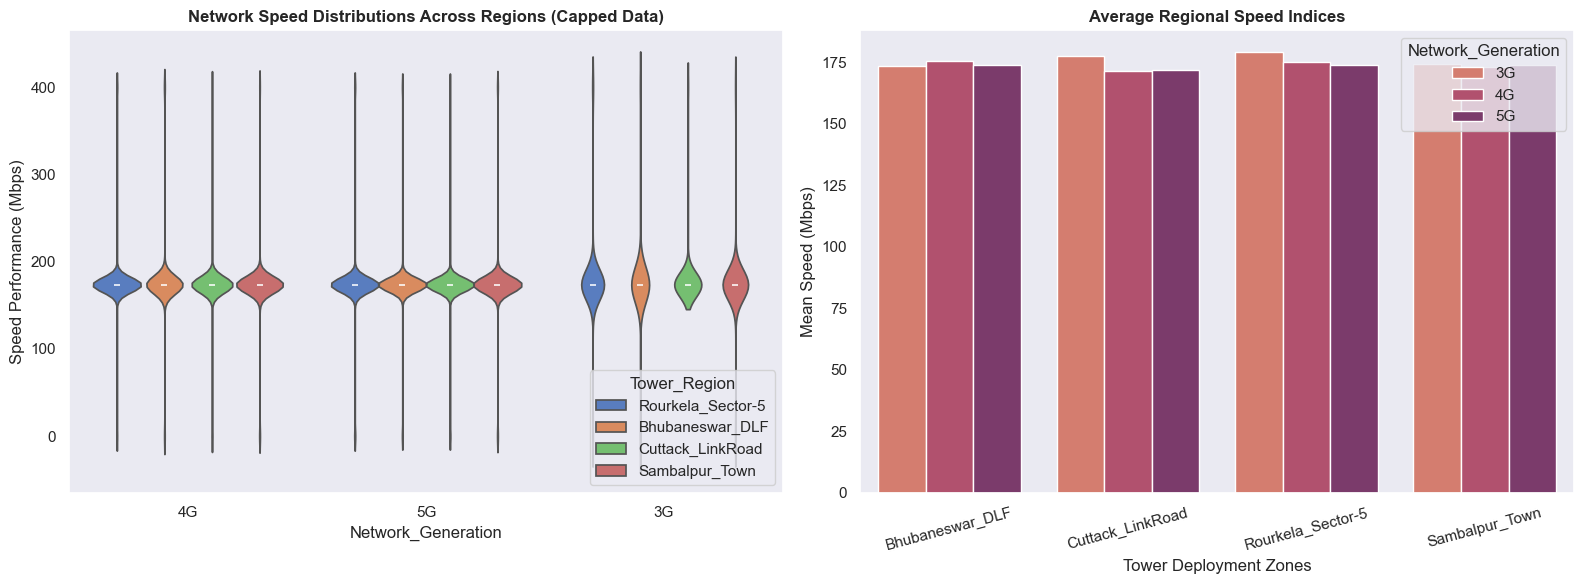

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Load raw network performance dataset
df = pd.read_csv('raw_telecom_network_logs.csv')

print("=== STEP 1: CRASH FLAG DISTRIBUTION ===")
print(df['Server_Crash_Flag'].value_counts())
print("=========================================\n")

# ================================================================
# 1. THE BITWISE INVERSION MASK (~)
# ================================================================
# Problem: We need to drop every single row where a server crash happend.
#  Action: Instead of keeping rows based on matching strings, create a mask for True Crashes and use the tilde(~) operator to instantly select the exact opposite (All False Rows).
crash_mask = df['Server_Crash_Flag'] == True
df_operational = df[~crash_mask].copy()

print("===  STEP 2: ROWS REMAINING AFTER INVERSION FILTER ===")
print(f"Original Logs: {df.shape[0]} | Clean Operational Logs: {df_operational.shape[0]}")
print("=========================================\n")

# ================================================================
# 2. BOUNDARY CLIPPING FOR SPEED OUTLIERS (.clip)
# =================================================================

# Problem: Glitched rows show -50 Mbps or 9999 Mbps, ruining our regional averages
# Actions: Keep rows intact, but cap/clip any speed value below 0 upto 0, and any value above 400 down to 400.
df_operational['Download_Speed_Mbps'] = df_operational['Download_Speed_Mbps'].clip(lower=0 , upper=400)

# ===================================================================
# 3. REGIONAL PERFORMANCE REPORTING
# ===================================================================

network_report = df_operational.groupby(['Tower_Region', 'Network_Generation']).agg(
    Total_Hours_Monitors = ('Log_ID','count'),
    Average_Download_Speed = ('Download_Speed_Mbps','mean'),
    Max_Speed_Recorded = ("Download_Speed_Mbps",'max')
).reset_index()

network_report.to_csv('cleaned_network_performance_report.csv', index=False)
print("💾 'cleaned_network_performance_report.csv' compiled successfully.\n")

# ==================================================================
# 4. TELECOM PERFORMANCE CHARTS
# ==================================================================

sns.set_theme(style='dark')
fig,axes = plt.subplots(1,2,figsize = (16,6))

# Chart A: Violin distribution showing data density after capping bounds
sns.violinplot(
    x ='Network_Generation',
    y ='Download_Speed_Mbps',
    hue ="Tower_Region",
    data = df_operational,
    palette='muted',
    ax = axes[0]
)

axes[0].set_title('Network Speed Distributions Across Regions (Capped Data)', fontweight='bold')
axes[0].set_ylabel('Speed Performance (Mbps)')

# Chart B: Performance comparison bar chart
sns.barplot(
    x = 'Tower_Region',
    y = "Average_Download_Speed",
    hue = "Network_Generation",
    data = network_report,
    palette='flare',
    ax = axes[1]
)
axes[1].set_title('Average Regional Speed Indices', fontweight='bold')
axes[1].set_xlabel('Tower Deployment Zones')
axes[1].set_ylabel('Mean Speed (Mbps)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

